In [1]:
import geopandas as gpd

fp = "../../data/cantons/swissBOUNDARIES3D_1_3_TLM_KANTONSGEBIET.shp"

# Read file using gpd.read_file()
data = gpd.read_file(fp)
type(data)


geopandas.geodataframe.GeoDataFrame

In [2]:
data.plot()

ImportError: The matplotlib package is required for plotting in geopandas. You can install it using 'conda install -c conda-forge matplotlib' or 'pip install matplotlib'.

In [32]:
matplotlib inline

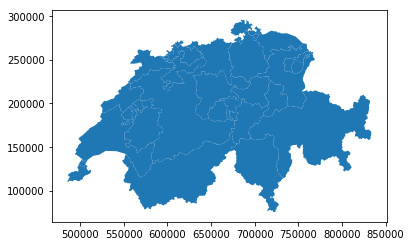

In [33]:
data.plot()

In [61]:
data.head(1)

,UUID,DATUM_AEND,DATUM_ERST,ERSTELL_J,ERSTELL_M,REVISION_J,REVISION_M,GRUND_AEND,HERKUNFT,HERKUNFT_J,...,OBJEKTART,REVISION_Q,ICC,KANTONSNUM,SEE_FLAECH,KANTONSFLA,KT_TEIL,NAME,EINWOHNERZ,geometry
0,{0B2364ED-49E0-4D53-A33C-C684DD530B57},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,Kanton,2018_Aufbau,CH,18,NaN,710530.0,0,Graubünden,197888.0,POLYGON Z ((709776.0697413046 185645.950723568...


In [62]:
print(data['geometry'].head(1).exterior)

0    LINEARRING Z (709776.0697413046 185645.9507235...
dtype: object


In [63]:
data['geometry'].head(1).area

0    7.105217e+09
dtype: float64

In [65]:
selection=data.loc[data['NAME']=='Vaud']
selection


,UUID,DATUM_AEND,DATUM_ERST,ERSTELL_J,ERSTELL_M,REVISION_J,REVISION_M,GRUND_AEND,HERKUNFT,HERKUNFT_J,...,OBJEKTART,REVISION_Q,ICC,KANTONSNUM,SEE_FLAECH,KANTONSFLA,KT_TEIL,NAME,EINWOHNERZ,geometry
3,{921DFEF2-6D91-4CB8-9CFC-2A831C412020},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,Kanton,2018_Aufbau,CH,22,39097.0,321201.0,1,Vaud,793129.0,POLYGON Z ((549756.7944861775 189303.15992634 ...
26,{DAD81A01-85E7-4FFC-B0C9-B2359730300E},2015-12-08,2012-10-26,2012,10,2019,1,Verbessert,AV,2015,...,Kanton,2018_Aufbau,CH,22,NaN,NaN,2,Vaud,NaN,POLYGON Z ((569696.1611532553 203238.821218004...


In [66]:
for idx,row in selection.iterrows():
    area=row['geometry'].area
    print("The geometry at {idx} is {area}").format(idx=idx,area=area)

The geometry at 3 is 3118536618.9
The geometry at 26 is 93463290.3216


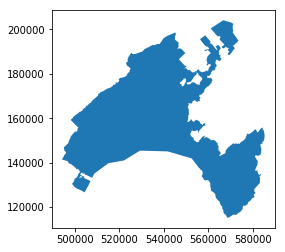

In [67]:
selection.plot()

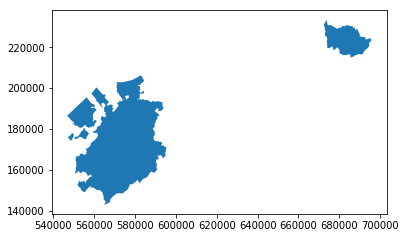

In [68]:
zugAndFribourg=data.loc[(data['NAME']=='Zug') | (data['NAME']=='Fribourg')]
zugAndFribourg.plot()

In [69]:

for idx,row in zugAndFribourg.iterrows():
    dist=row['geometry'].distance(data.loc[6]['geometry'])
    print("distance from {x} to {y} is {d}").format(x=data.loc[8]['NAME'],y=row['NAME'],d=dist)

distance from Luzern to Fribourg is 89285.8176542
distance from Luzern to Zug is 0.0
distance from Luzern to Fribourg is 120366.375973
distance from Luzern to Fribourg is 128313.159856
distance from Luzern to Fribourg is 135083.448233
distance from Luzern to Fribourg is 95400.1243037
distance from Luzern to Fribourg is 118589.427963


In [70]:
newData=gpd.GeoDataFrame()
newData['geometry']=None

data['center']=None

for idx,row in data.iterrows():
    center=row['geometry'].centroid
    data.loc[idx,'center']=center

In [71]:
df=gpd.GeoDataFrame(data['center'])
df
conversion={'center':'geometry'}
df.rename(columns=conversion)

,geometry
0,POINT (767575.0244501946 169561.5515886946)
1,POINT (614277.2987648115 185601.5741448295)
2,POINT (612816.6401953455 117581.908002399)
3,POINT (539303.7917365739 156760.3369243431)
4,POINT (705582.446308137 128055.1089343966)
5,POINT (739058.4421031841 233039.9063328989)
6,POINT (691804.3897484293 252035.1222239229)
7,POINT (573827.5419753399 173065.4281091813)
8,POINT (651010.0992641809 213189.1664508271)
9,POINT (654217.6257056012 251244.1736071813)


In [72]:
df.crs=data.crs

In [73]:
df.crs

{u'ellps': u'bessel',
 u'k_0': 1,
 u'lat_0': 46.95240555555556,
 u'lon_0': 7.439583333333333,
 u'no_defs': True,
 u'proj': u'somerc',
 u'units': u'm',
 u'x_0': 600000,
 u'y_0': 200000}

In [74]:
df=df.set_geometry('center')

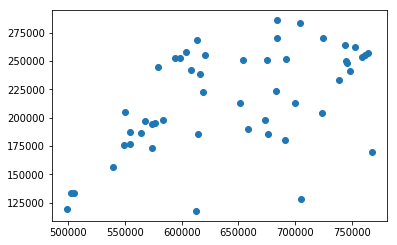

In [75]:
df.plot()

In [ ]:
df.to_file('swissCenters.shp')